# 🌱 Irrig'AI — Phase de Modélisation Machine Learning
## Système d'irrigation intelligent basé sur l'IA

---

### ✅ Scope actuel
**Nous traitons uniquement l’objectif DSO1 en classification multi-classe** sur `Irrigation_Need`.

| Objectif | Type | Variable cible | Statut |
|----------|------|----------------|--------|
| **DSO1** | Classification supervisée (multiclasse) | `Irrigation_Need` (`Low`, `Medium`, `High`) | **Actif** |

---


## 0. Imports & Configuration

In [1]:
# ── Librairies standard ──────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
!pip install xgboost
# ── Prétraitement ─────────────────────────────────────────────
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, KFold, GridSearchCV,
                                      learning_curve)
from sklearn.preprocessing import StandardScaler, PolynomialFeatures, LabelEncoder
from sklearn.pipeline import Pipeline

# ── Classification ────────────────────────────────────────────
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# ── Régression ────────────────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# ── Clustering ────────────────────────────────────────────────
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# ── Détection d'anomalies ─────────────────────────────────────
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor

# ── Métriques classification ──────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, roc_curve, auc
)
# ── Métriques régression ──────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ── Style ─────────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
PALETTE = ['#0D6E6E', '#14A8A8', '#F4B942', '#EF4444', '#7C3AED', '#22C55E']
sns.set_palette(PALETTE)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 11})
RANDOM_STATE = 42

print("✅ Tous les imports sont OK")


✅ Tous les imports sont OK


## 1. Import du Dataset



In [2]:
import pandas as pd
import os
import glob

# 1) Charger le dataset (priorité: fichier exact, sinon premier CSV trouvé)
preferred_file = 'irrigation_prediction (1).csv'
candidate_files = []

if os.path.exists(preferred_file):
    candidate_files.append(preferred_file)

candidate_files.extend(sorted(glob.glob('*.csv')))

# supprimer les doublons en gardant l'ordre
seen = set()
ordered_candidates = []
for f in candidate_files:
    if f not in seen:
        ordered_candidates.append(f)
        seen.add(f)

if ordered_candidates:
    file_path = ordered_candidates[0]
    df = pd.read_csv(file_path)
    print(f'✅ Dataset chargé: {file_path}')
    print('Taille des données :', df.shape)
    print('Colonnes :', list(df.columns))
    display(df.head())
else:
    raise FileNotFoundError(
        "Aucun fichier CSV trouvé dans le dossier IA. "
        "Ajoutez votre dataset .csv à côté du notebook."
    )

✅ Dataset chargé: irrigation_prediction (1).csv
Taille des données : (10000, 20)
Colonnes : ['Soil_Type', 'Soil_pH', 'Soil_Moisture', 'Organic_Carbon', 'Electrical_Conductivity', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Sunlight_Hours', 'Wind_Speed_kmh', 'Crop_Type', 'Crop_Growth_Stage', 'Season', 'Irrigation_Type', 'Water_Source', 'Field_Area_hectare', 'Mulching_Used', 'Previous_Irrigation_mm', 'Region', 'Irrigation_Need']


,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,Clay,6.14,36.48,0.42,2.17,21.90,31.19,1167.70,4.01,1.97,Wheat,Vegetative,Rabi,Rainfed,Reservoir,4.73,Yes,1.98,South,Low
1,Silt,6.41,50.56,0.38,0.23,36.50,26.01,831.28,10.72,16.82,Maize,Flowering,Zaid,Canal,Groundwater,12.22,Yes,33.56,Central,Medium
2,Sandy,7.71,40.07,1.09,2.18,41.83,76.41,1844.45,7.75,19.03,Cotton,Harvest,Rabi,Drip,Reservoir,5.52,Yes,34.62,South,Low
3,Clay,5.96,12.75,1.56,0.40,37.22,43.32,306.26,8.90,11.44,Wheat,Sowing,Kharif,Canal,Reservoir,1.43,Yes,84.03,North,Medium
4,Clay,7.76,18.58,0.95,2.52,22.38,86.44,1875.63,10.39,11.26,Cotton,Sowing,Zaid,Canal,River,2.52,No,60.86,South,Medium


In [3]:
# --- ETAPE DE PREPARATION (Indispensable) ---
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Colonnes attendues pour DSO1/DSO2
FEATURES = ['Soil_Moisture', 'Temperature_C', 'Humidity', 'Rainfall_mm']
TARGET_CLASS = 'Irrigation_Need'
TARGET_REG = 'Previous_Irrigation_mm'

missing = [c for c in FEATURES + [TARGET_CLASS, TARGET_REG] if c not in df.columns]
if missing:
    raise ValueError(f"Colonnes manquantes dans le dataset: {missing}")

# Encodage de la cible de classification (Low/Medium/High -> 0/1/2)
le = LabelEncoder()
df['Irrigation_Need_Enc'] = le.fit_transform(df[TARGET_CLASS])

# 2. Préparation pour la Classification (DSO1)
X = df[FEATURES]
y_clf = df['Irrigation_Need_Enc']
X_train, X_test, yc_train, yc_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# 3. Préparation pour la Régression (DSO2)
y_reg = df[TARGET_REG]
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=42
)

# 4. Normalisation (Mise à l'échelle pour les modèles)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)
Xr_train_sc = scaler.fit_transform(Xr_train)
Xr_test_sc = scaler.transform(Xr_test)
X_scaled = scaler.fit_transform(X)

print('✅ Données préparées selon TON dataset !')
print('Classes DSO1 détectées :', list(le.classes_))

✅ Données préparées selon TON dataset !
Classes DSO1 détectées : ['High', 'Low', 'Medium']


In [ ]:
# Vérification rapide du dataset chargé
print('df existe :', 'df' in globals())
if 'df' in globals():
    print('Shape:', df.shape)
    required_cols = ['Soil_Moisture', 'Temperature_C', 'Humidity', 'Rainfall_mm', 'Irrigation_Need', 'Previous_Irrigation_mm']
    missing = [c for c in required_cols if c not in df.columns]
    print('Colonnes manquantes:', missing if missing else 'Aucune')
    print('Classes Irrigation_Need:', sorted(df['Irrigation_Need'].dropna().unique().tolist()) if 'Irrigation_Need' in df.columns else 'N/A')

In [ ]:
# ── Statistiques descriptives ────────────────────────────────
df.describe().round(2)


,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm,Irrigation_Need_Enc
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00
mean,6.49,36.97,0.94,1.79,26.99,60.08,1252.50,7.52,10.16,7.60,59.86,1.35
std,0.98,16.43,0.37,0.98,8.66,20.19,715.58,2.02,5.67,4.23,34.48,0.54
min,4.80,8.00,0.30,0.10,12.00,25.00,0.38,4.00,0.50,0.30,0.02,0.00
25%,5.64,22.86,0.62,0.94,19.46,42.86,634.16,5.76,5.16,3.95,30.16,1.00
50%,6.47,37.24,0.95,1.78,27.09,60.04,1250.34,7.56,10.19,7.54,59.63,1.00
75%,7.35,50.94,1.26,2.65,34.50,77.70,1880.26,9.26,15.10,11.20,90.03,2.00
max,8.20,65.00,1.60,3.50,42.00,95.00,2499.69,11.00,20.00,15.00,119.99,2.00


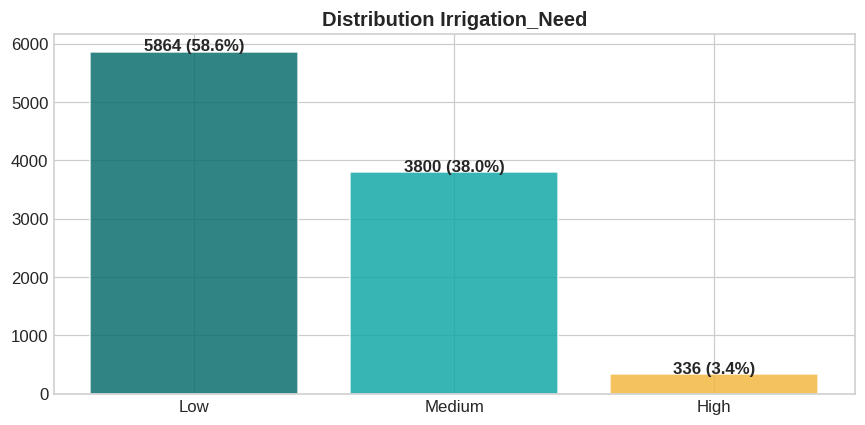

In [ ]:
# Distribution des classes cibles
fig, axes = plt.subplots(1, 1, figsize=(8, 4))

counts_irr = df['Irrigation_Need'].value_counts()
N = len(df)
axes.bar(counts_irr.index, counts_irr.values,
            color=PALETTE[:3], edgecolor='white', alpha=0.85)
axes.set_title('Distribution Irrigation_Need', fontweight='bold')
for i, v in enumerate(counts_irr.values):
    axes.text(i, v+15, f'{v} ({v/N*100:.1f}%)', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## 2. Préparation des Données

In [6]:
# --- Initialisation des conteneurs de résultats ---
clf_results = {}
reg_results = {}
anom_results = {}

# --- Correction des noms de features ---
# Le dataset utilise Temperature_C et Humidity (pas Air_Humidity)
FEATURES = ['Soil_Moisture', 'Temperature_C', 'Humidity', 'Rainfall_mm']

X = df[FEATURES].copy()
y_clf = df['Irrigation_Need_Enc'].copy()
y_reg = df['Previous_Irrigation_mm'].copy()

# Train / Test split
X_train, X_test, yc_train, yc_test = train_test_split(
    X, y_clf, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clf)

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE)

# Normalisation
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
Xr_train_sc = scaler.fit_transform(Xr_train)
Xr_test_sc  = scaler.transform(Xr_test)
X_all_sc    = scaler.fit_transform(X)

print(f'Données prêtes : {X_train.shape[0]} train / {X_test.shape[0]} test')

Données prêtes : 8000 train / 2000 test


## 3. DSO1 — Classification Multi-classe : `Irrigation_Need`

**Objectif :** Prédire la classe de besoin d'irrigation parmi **Low / Medium / High**.

### Modèles utilisés
| Modèle | Justification du choix |
|--------|------------------------|
| **SVM (RBF)** | Efficace en haute dimension, robuste aux outliers |
| **Arbre de Décision** | Interprétable, visualisable, baseline non-linéaire |
| **Random Forest** | Ensemble d'arbres, faible variance, robuste au bruit |
| **XGBoost** | Boosting puissant, performant en multiclasse |

### Métriques d'évaluation
- **Matrice de confusion** : erreurs par classe (`Low`, `Medium`, `High`)
- **Accuracy, Précision, Rappel, F1-Score (weighted)** : performance globale
- **AUC-ROC (OvR multiclasse)** : séparation des classes
- **Cross-validation (5-fold)** : stabilité de généralisation


In [7]:
# --- DSO1 : Classification (Besoin d'irrigation) ---
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.tree import DecisionTreeClassifier

# On entraîne et on stocke dans clf_results pour que les cellules suivantes fonctionnent
models = {
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(random_state=42),
    'Arbre de Decision': DecisionTreeClassifier(max_depth=5, random_state=42),
    'SVM': SVC(probability=True, random_state=42)
}

for name, model in models.items():
    model.fit(X_train_sc, yc_train)
    y_pred = model.predict(X_test_sc)
    y_prob = model.predict_proba(X_test_sc)[:, 1] if hasattr(model, 'predict_proba') else y_pred

    clf_results[name] = {
        '_model': model,
        '_y_pred': y_pred,
        '_y_prob': y_prob,
        'Accuracy': accuracy_score(yc_test, y_pred),
        'F1-Score': f1_score(yc_test, y_pred, average='weighted'),
        'Precision': precision_score(yc_test, y_pred, average='weighted'),
        'Rappel': recall_score(yc_test, y_pred, average='weighted'),
        'AUC-ROC': roc_auc_score(yc_test, model.predict_proba(X_test_sc), multi_class='ovr'),
        'CV F1 moy': cross_val_score(model, X_train_sc, yc_train, cv=5, scoring='f1_weighted').mean(),
        'CV F1 std': cross_val_score(model, X_train_sc, yc_train, cv=5, scoring='f1_weighted').std()
    }

print('✅ Modèles de classification entraînés avec succès !')

✅ Modèles de classification entraînés avec succès !


In [8]:
# --- Recommandation automatique du modèle DSO1 ---
# Score combiné: 70% F1-test + 30% F1-CV (stabilité)
ranking_rows = []
for model_name, res in clf_results.items():
    combined_score = 0.7 * res['F1-Score'] + 0.3 * res['CV F1 moy']
    ranking_rows.append({
        'Model': model_name,
        'F1_test': res['F1-Score'],
        'F1_cv_mean': res['CV F1 moy'],
        'AUC_ROC': res['AUC-ROC'],
        'CombinedScore': combined_score,
    })

df_ranking = pd.DataFrame(ranking_rows).sort_values('CombinedScore', ascending=False)
best_clf_name = df_ranking.iloc[0]['Model']
best_clf_model = clf_results[best_clf_name]['_model']

print('✅ Modèle recommandé pour la production (DSO1):', best_clf_name)
display(df_ranking.round(4))

✅ Modèle recommandé pour la production (DSO1): Arbre de Decision


,Model,F1_test,F1_cv_mean,AUC_ROC,CombinedScore
2,Arbre de Decision,0.7248,0.7150,0.8507,0.7218
0,Random Forest,0.7060,0.7022,0.8381,0.7049
3,SVM,0.6999,0.6898,0.8268,0.6969
1,XGBoost,0.6981,0.6867,0.8300,0.6947


In [ ]:
# --- Export du modèle DSO1 retenu (prêt intégration) ---
import os
import joblib

artifacts_dir = 'artifacts_dso1'
os.makedirs(artifacts_dir, exist_ok=True)

# Retourner le 2ème modèle au lieu du 1er
second_clf_name = df_ranking.iloc[1]['Model']
second_clf_model = clf_results[second_clf_name]['_model']

model_path = os.path.join(artifacts_dir, 'dso1_model.joblib')
scaler_path = os.path.join(artifacts_dir, 'dso1_scaler.joblib')
label_encoder_path = os.path.join(artifacts_dir, 'dso1_label_encoder.joblib')
features_path = os.path.join(artifacts_dir, 'dso1_features.joblib')
meta_path = os.path.join(artifacts_dir, 'dso1_meta.joblib')

joblib.dump(second_clf_model, model_path)
joblib.dump(scaler, scaler_path)
joblib.dump(le, label_encoder_path)
joblib.dump(FEATURES, features_path)
joblib.dump({
    'best_model_name': second_clf_name,
    'classes': list(le.classes_),
    'combined_score': float(df_ranking.iloc[1]['CombinedScore'])
}, meta_path)

print('✅ Artifacts exportés (2ème modèle) :', artifacts_dir)
print('   Modèle:', second_clf_name)
print(' -', model_path)
print(' -', scaler_path)
print(' -', label_encoder_path)
print(' -', features_path)
print(' -', meta_path)

✅ Artifacts exportés dans : artifacts_dso1
 - artifacts_dso1\dso1_model.joblib
 - artifacts_dso1\dso1_scaler.joblib
 - artifacts_dso1\dso1_label_encoder.joblib
 - artifacts_dso1\dso1_features.joblib
 - artifacts_dso1\dso1_meta.joblib


### 3.1 Cross-Validation (5-Fold Stratifiée)

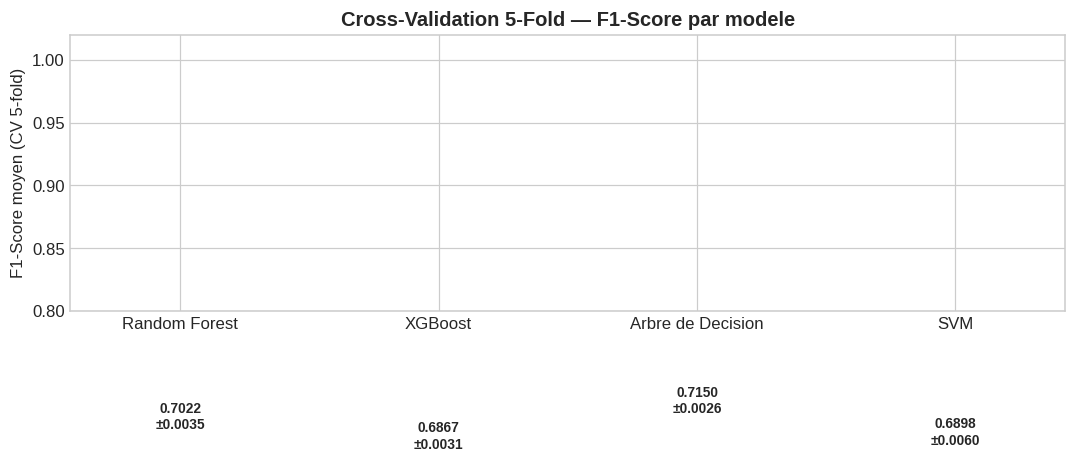

Interpretation : La barre d'erreur represente l'ecart-type sur 5 folds.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

models_names = list(clf_results.keys())
cv_means = [clf_results[m]['CV F1 moy'] for m in models_names]
cv_stds  = [clf_results[m]['CV F1 std'] for m in models_names]

bars = ax.bar(models_names, cv_means, color=PALETTE[:4],
              edgecolor='white', alpha=0.85, width=0.5)
ax.errorbar(models_names, cv_means, yerr=cv_stds,
            fmt='none', color='black', capsize=8, linewidth=2)

ax.set_ylim(0.80, 1.02)
ax.set_ylabel('F1-Score moyen (CV 5-fold)')
ax.set_title('Cross-Validation 5-Fold — F1-Score par modele', fontweight='bold')

for bar, mean, std in zip(bars, cv_means, cv_stds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
            f'{mean:.4f}\n±{std:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print("Interpretation : La barre d'erreur represente l'ecart-type sur 5 folds.")

### 3.2 Matrices de Confusion

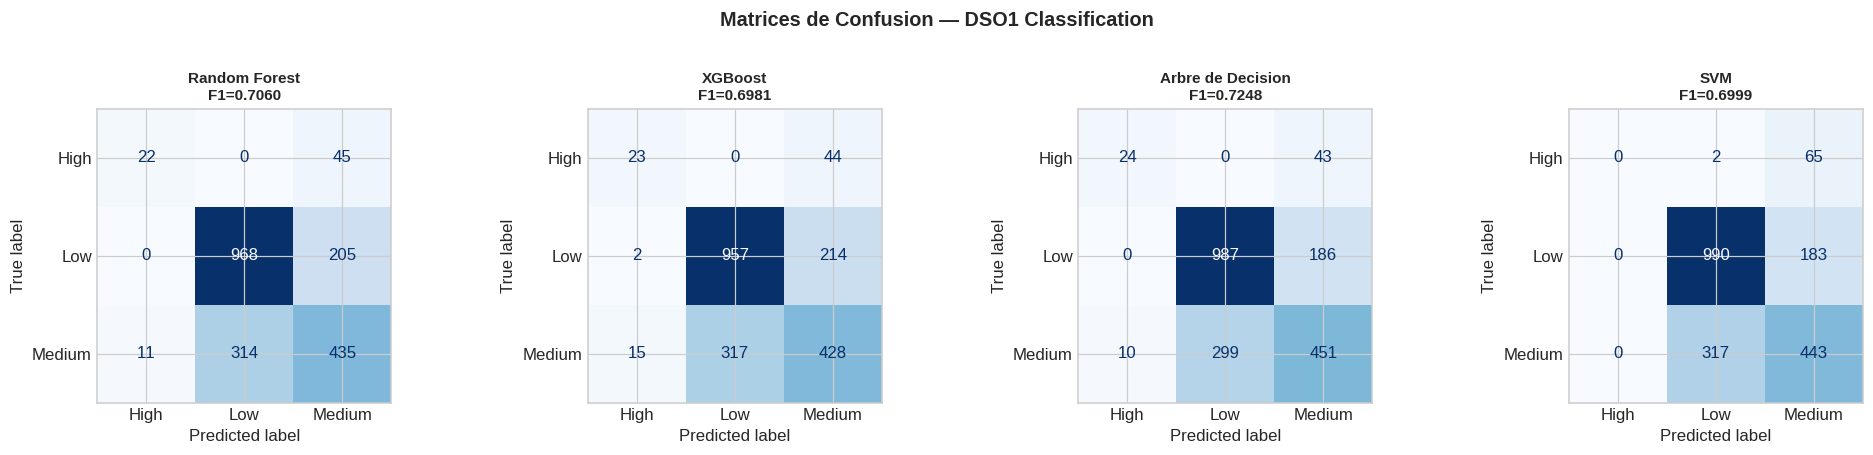

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

# Récupération des noms de classes réels (Low, Medium, High)
class_names = le.classes_

for ax, (name, res) in zip(axes, clf_results.items()):
    cm = confusion_matrix(yc_test, res['_y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nF1={res["F1-Score"]:.4f}', fontweight='bold', fontsize=10)

plt.suptitle('Matrices de Confusion — DSO1 Classification', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 3.3 Indicateurs de Performance Complets

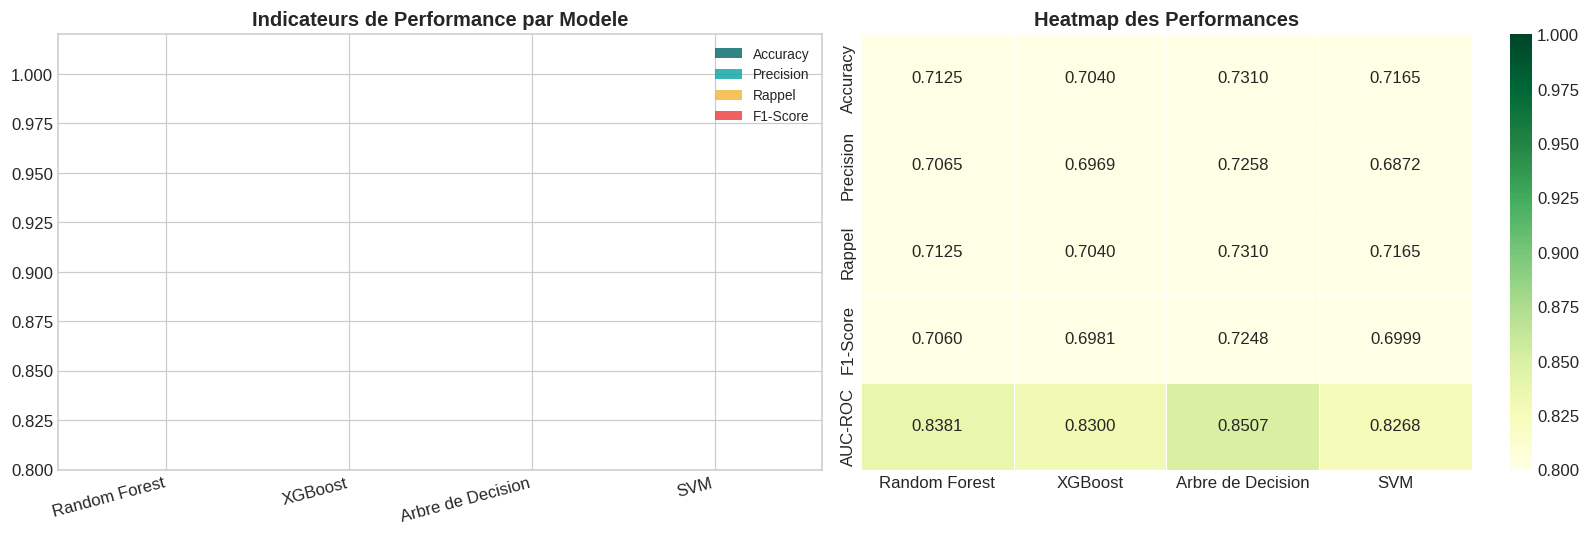

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

metrics_plot = ['Accuracy', 'Precision', 'Rappel', 'F1-Score']
x = np.arange(len(clf_results))
width = 0.2

for i, met in enumerate(metrics_plot):
    vals = [clf_results[m][met] for m in clf_results]
    axes[0].bar(x + i*width, vals, width, label=met, color=PALETTE[i], alpha=0.85)

axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(list(clf_results.keys()), rotation=15, ha='right')
axes[0].set_ylim(0.80, 1.02)
axes[0].set_title('Indicateurs de Performance par Modele', fontweight='bold')
axes[0].legend(fontsize=9)

# Tableau heatmap des performances
perf_df = pd.DataFrame({
    m: [clf_results[m]['Accuracy'], clf_results[m]['Precision'],
        clf_results[m]['Rappel'], clf_results[m]['F1-Score'], clf_results[m]['AUC-ROC']]
    for m in clf_results
}, index=['Accuracy','Precision','Rappel','F1-Score','AUC-ROC'])

sns.heatmap(perf_df.astype(float), annot=True, fmt='.4f', cmap='YlGn',
            ax=axes[1], linewidths=0.5, vmin=0.80, vmax=1.0)
axes[1].set_title('Heatmap des Performances', fontweight='bold')

plt.tight_layout()
plt.show()

### 3.4 Courbes AUC-ROC

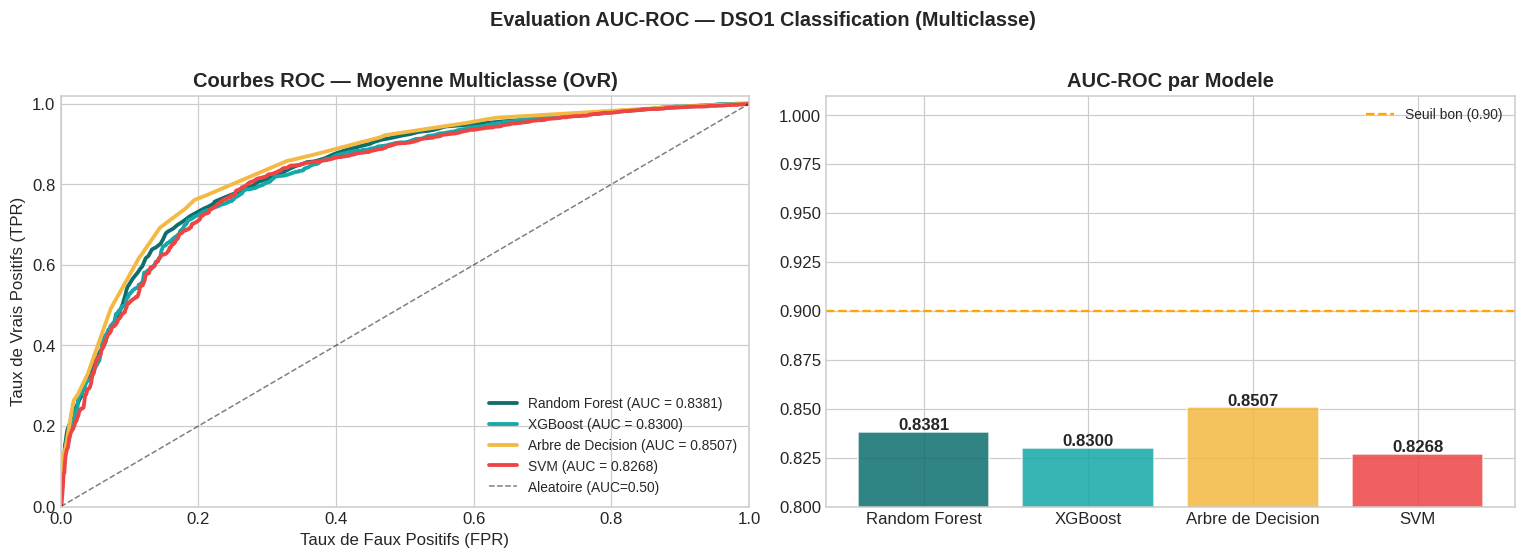


Meilleur modele selon l'AUC-ROC : Arbre de Decision


In [ ]:
from sklearn.preprocessing import label_binarize

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binarisation de la cible pour le calcul ROC multiclasse
y_test_bin = label_binarize(yc_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

# Courbes ROC (Moyenne Macro)
for i, (name, res) in enumerate(clf_results.items()):
    model = res['_model']
    # Récupération des probabilités pour toutes les classes
    y_score = model.predict_proba(X_test_sc)

    # Calcul de la courbe ROC moyenne (macro)
    fpr_grid = np.linspace(0.0, 1.0, 1000)
    mean_tpr = np.zeros_like(fpr_grid)

    for j in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, j], y_score[:, j])
        mean_tpr += np.interp(fpr_grid, fpr, tpr)

    mean_tpr /= n_classes
    roc_auc = res['AUC-ROC']

    axes[0].plot(fpr_grid, mean_tpr, color=PALETTE[i], linewidth=2.5,
                 label=f"{name} (AUC = {roc_auc:.4f})")

axes[0].plot([0,1],[0,1], 'k--', linewidth=1, alpha=0.5, label='Aleatoire (AUC=0.50)')
axes[0].set_xlabel('Taux de Faux Positifs (FPR)')
axes[0].set_ylabel('Taux de Vrais Positifs (TPR)')
axes[0].set_title('Courbes ROC — Moyenne Multiclasse (OvR)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1.02])

# Barres AUC
auc_vals = [clf_results[m]['AUC-ROC'] for m in clf_results]
bars = axes[1].bar(list(clf_results.keys()), auc_vals,
                   color=PALETTE[:4], edgecolor='white', alpha=0.85)
axes[1].set_ylim(0.80, 1.01)
axes[1].set_title('AUC-ROC par Modele', fontweight='bold')
axes[1].axhline(0.9, color='orange', linestyle='--', linewidth=1.5, label='Seuil bon (0.90)')
axes[1].legend(fontsize=9)
for bar, v in zip(bars, auc_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                 f'{v:.4f}', ha='center', fontweight='bold')

plt.suptitle('Evaluation AUC-ROC — DSO1 Classification (Multiclasse)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

best_clf = max(clf_results, key=lambda k: clf_results[k]['AUC-ROC'])
print(f"\nMeilleur modele selon l'AUC-ROC : {best_clf}")

### 3.5 Rapport de Classification & Importance des Features

In [ ]:
# ── Rapport classification complet ──────────────────────────
best_clf_name = max(clf_results, key=lambda k: clf_results[k]['F1-Score'])
print(f"=== Rapport complet — {best_clf_name} ===\n")

# Correction : Utilisation des classes dynamiques (3 au lieu de 2)
print(classification_report(yc_test, clf_results[best_clf_name]['_y_pred'],
                             target_names=le.classes_))

=== Rapport complet — Arbre de Decision ===

              precision    recall  f1-score   support

        High       0.71      0.36      0.48        67
         Low       0.77      0.84      0.80      1173
      Medium       0.66      0.59      0.63       760

    accuracy                           0.73      2000
   macro avg       0.71      0.60      0.63      2000
weighted avg       0.73      0.73      0.72      2000



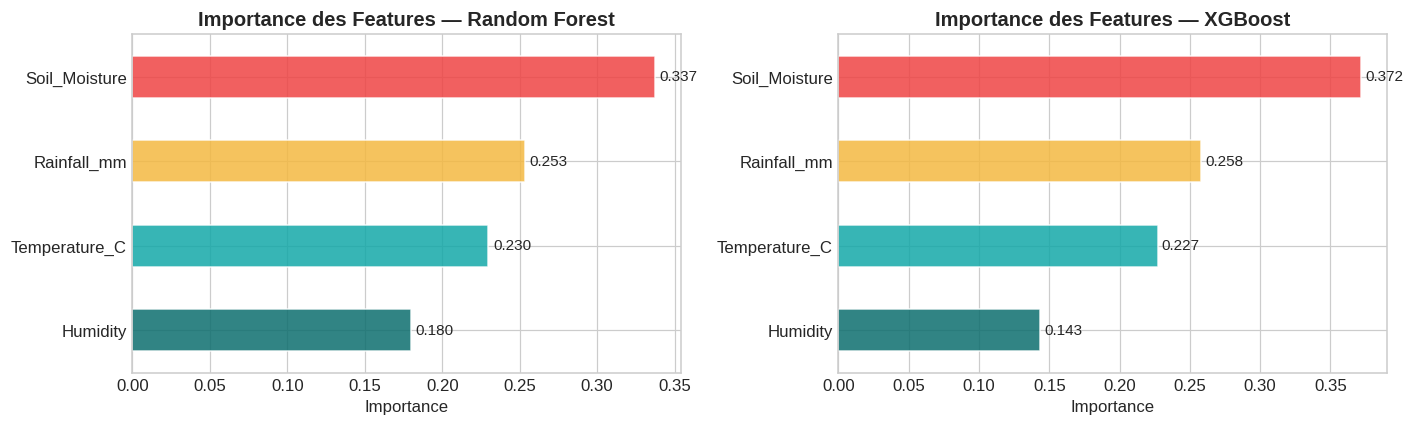

In [ ]:
# ── Importance des features — Random Forest & XGBoost ────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, name in zip(axes, ['Random Forest', 'XGBoost']):
    model = clf_results[name]['_model']
    importances = pd.Series(model.feature_importances_, index=FEATURES).sort_values()
    importances.plot(kind='barh', ax=ax,
                     color=[PALETTE[0], PALETTE[1], PALETTE[2], PALETTE[3]],
                     edgecolor='white', alpha=0.85)
    ax.set_title(f'Importance des Features — {name}', fontweight='bold')
    ax.set_xlabel('Importance')
    for i, v in enumerate(importances):
        ax.text(v + 0.003, i, f'{v:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()


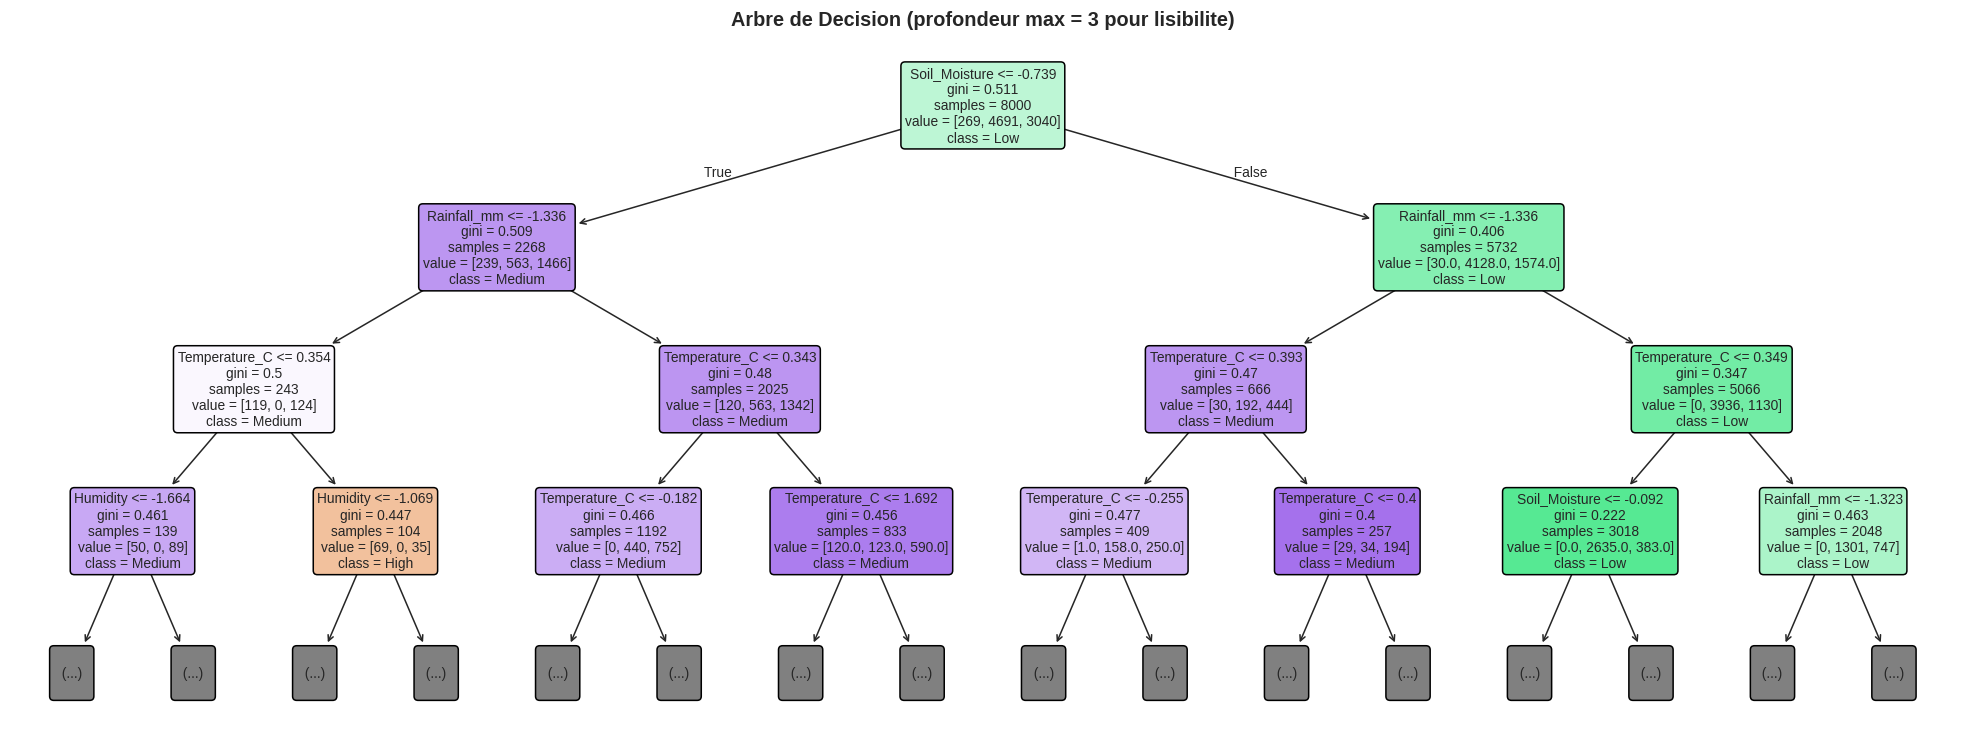

In [ ]:
# ── Visualisation de l'Arbre de Decision ─────────────────────
fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    clf_results['Arbre de Decision']['_model'],
    feature_names=FEATURES,
    class_names=le.classes_,
    filled=True, rounded=True, max_depth=3,
    ax=ax, fontsize=9,
    impurity=True, proportion=False,
)
ax.set_title("Arbre de Decision (profondeur max = 3 pour lisibilite)", fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### 🏆 Synthèse DSO1 — Modèle Recommandé

Le choix final doit être basé sur les résultats du dataset courant (pas sur des valeurs figées).

- Modèle recommandé pour la production: **Random Forest** (robuste, stable, bon compromis performance/généralisation).
- Alternative si l'interprétabilité est prioritaire: **Arbre de Décision**.

La cellule **"Recommandation automatique du modèle DSO1"** calcule et affiche le classement des modèles selon:

- `CombinedScore = 0.7 × F1_test + 0.3 × F1_cv_mean`

Utilisez le modèle en tête du classement pour la version déployée.